# Análise de Métricas de Retrieval

**Projeto:** Issue #1 - Comparativo de Modelos de Embedding PT-BR  
**Data:** 2026-04-09  
**Responsável:** Luis Felipe de Moraes

---

## Objetivo

Visualizar e comparar as métricas de retrieval dos 9 modelos de embedding testados:
- Comparação Taxa de Recuperação vs NDCG@10
- Ranking por múltiplas métricas
- Correlação entre métricas
- Análise de viés metodológico (overlap de documentos)
- Distribuição de scores por query

In [55]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Configuração de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Cores consistentes para modelos
MODEL_COLORS = {
    'bge-m3': "#81cfa2",  # Verde (vencedor)
    'multilingual-e5-small': "#86b9db",  # Azul
    'multilingual-e5-base': "#9f6cb3",  # Roxo
    'multilingual-e5-large': "#e99c93",  # Vermelho
    'labse': "#f0c37c",  # Laranja
    'serafim': "#74beb0",  # Turquesa
    'paraphrase-mpnet': "#5c6975",  # Cinza escuro
    'paraphrase-miniml': '#95a5a6',  # Cinza claro
    'bertimbau': "#e4b083"  # Laranja escuro
}

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento de Dados

In [56]:
# Carregar métricas resumidas
metrics_df = pd.read_csv('../results/metrics/metrics_summary.csv')

# Remover ndcg@20 (inválido - apenas 10 anotações por query)
if 'ndcg@20' in metrics_df.columns:
    metrics_df = metrics_df.drop(columns=['ndcg@20'])

# Carregar resultados completos
with open('../results/metrics/evaluation_results.json') as f:
    full_results = json.load(f)

# Carregar ground truth
with open('../data/annotations/ground_truth.json') as f:
    ground_truth = json.load(f)

print(f"Métricas carregadas para {len(metrics_df)} modelos")
print(f"Ground truth: {len(ground_truth)} queries anotadas")
print(f"Colunas: {list(metrics_df.columns)}")

# Exibir tabela de métricas (sem ndcg@20)
metrics_df.sort_values('ndcg@10', ascending=False)

Métricas carregadas para 9 modelos
Ground truth: 259 queries anotadas
Colunas: ['model', 'ndcg@5', 'ndcg@10', 'map', 'mrr', 'recall@10']


,model,ndcg@5,ndcg@10,map,mrr,recall@10
0,bge-m3,0.9371,0.9673,0.9006,0.9961,0.9992
1,multilingual-e5-small,0.8637,0.8858,0.7793,0.9685,0.8443
2,multilingual-e5-base,0.8466,0.8670,0.7493,0.9516,0.8347
3,multilingual-e5-large,0.8316,0.8545,0.7353,0.9297,0.8359
4,labse,0.7099,0.7371,0.6351,0.8350,0.7236
5,serafim,0.6124,0.6502,0.5472,0.7325,0.6569
6,paraphrase-mpnet,0.5526,0.5859,0.5051,0.6766,0.6314
7,paraphrase-miniml,0.4740,0.5049,0.4199,0.5808,0.5501
8,bertimbau,0.3705,0.4181,0.3311,0.4686,0.4947


In [57]:
# Calcular Taxa de Recuperação para cada modelo
recovery_rates = {}

for model_name in metrics_df['model']:
    model_file = f'../results/search_results/{model_name}_results.json'
    
    if not Path(model_file).exists():
        continue
    
    with open(model_file) as f:
        results = json.load(f)
    
    found_in_top10 = 0
    total_queries = 0
    
    for query_id, gt_docs in ground_truth.items():
        if query_id not in results:
            continue
        
        # Encontrar documento âncora (relevância = 3)
        anchor_docs = [doc_id for doc_id, score in gt_docs.items() if score == 3]
        if not anchor_docs:
            continue
        
        anchor = anchor_docs[0]
        top10_docs = [r['doc_id'] for r in results[query_id]['results'][:10]]
        
        total_queries += 1
        if anchor in top10_docs:
            found_in_top10 += 1
    
    recovery_rates[model_name] = (found_in_top10 / total_queries) * 100 if total_queries > 0 else 0

# Adicionar ao DataFrame
metrics_df['recovery_rate'] = metrics_df['model'].map(recovery_rates)

print("Taxa de Recuperação calculada para todos os modelos")
metrics_df[['model', 'recovery_rate', 'ndcg@10']].sort_values('recovery_rate', ascending=False)

Taxa de Recuperação calculada para todos os modelos


,model,recovery_rate,ndcg@10
0,bge-m3,99.612403,0.9673
3,multilingual-e5-large,99.224806,0.8545
1,multilingual-e5-small,98.837209,0.8858
2,multilingual-e5-base,98.837209,0.8670
4,labse,90.697674,0.7371
5,serafim,84.496124,0.6502
6,paraphrase-mpnet,76.744186,0.5859
8,bertimbau,68.217054,0.4181
7,paraphrase-miniml,67.054264,0.5049


## 2. Comparação: Taxa de Recuperação vs NDCG@10

Visualização que mostra como NDCG@10 discrimina melhor a qualidade dos modelos.

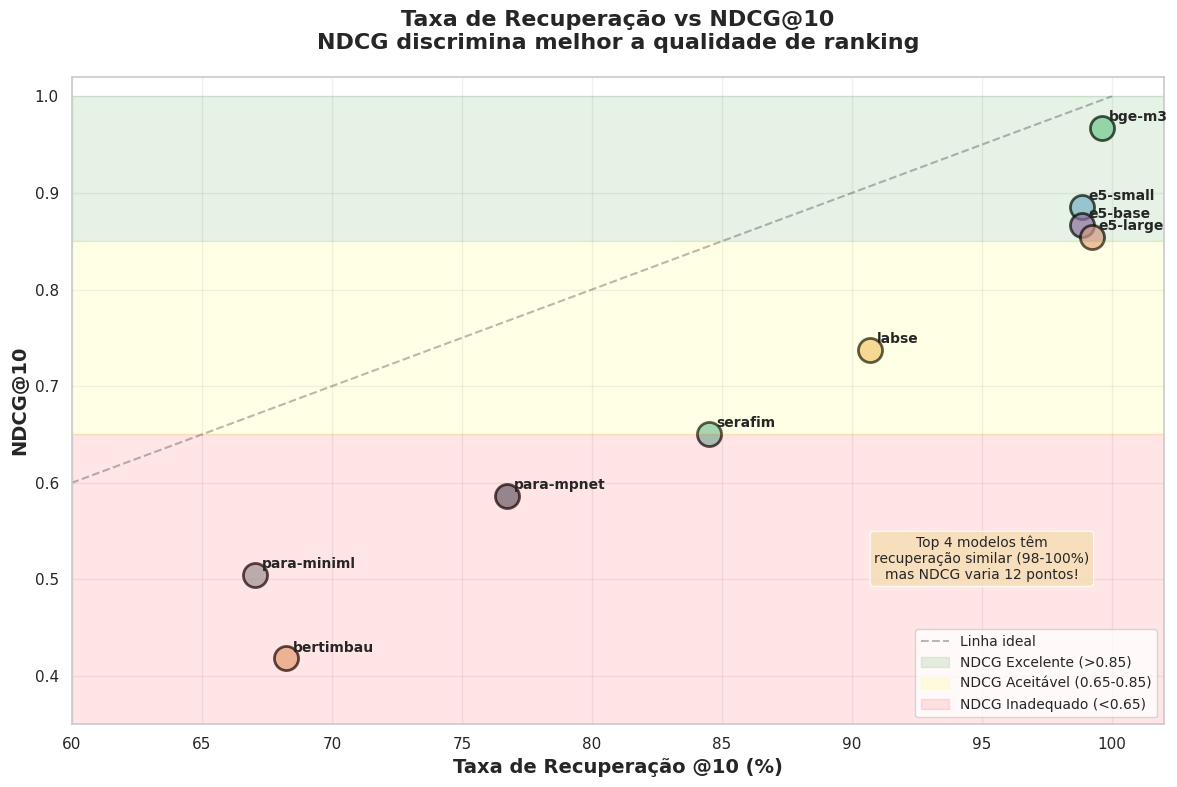

Gráfico salvo em: results/visualizations/recovery_vs_ndcg.png


In [58]:
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
for _, row in metrics_df.iterrows():
    model = row['model']
    ax.scatter(
        row['recovery_rate'], 
        row['ndcg@10'],
        s=300,
        color=MODEL_COLORS.get(model, 'gray'),
        alpha=0.7,
        edgecolors='black',
        linewidth=2
    )
    ax.annotate(
        model.replace('multilingual-e5-', 'e5-').replace('paraphrase-', 'para-'),
        (row['recovery_rate'], row['ndcg@10']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# Linha de referência ideal (recovery = NDCG)
ax.plot([0, 100], [0, 1], 'k--', alpha=0.3, label='Linha ideal')

# Regiões de interpretação
ax.axhspan(0.85, 1.0, alpha=0.1, color='green', label='NDCG Excelente (>0.85)')
ax.axhspan(0.65, 0.85, alpha=0.1, color='yellow', label='NDCG Aceitável (0.65-0.85)')
ax.axhspan(0, 0.65, alpha=0.1, color='red', label='NDCG Inadequado (<0.65)')

ax.set_xlabel('Taxa de Recuperação @10 (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('NDCG@10', fontsize=14, fontweight='bold')
ax.set_title('Taxa de Recuperação vs NDCG@10\nNDCG discrimina melhor a qualidade de ranking', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(60, 102)
ax.set_ylim(0.35, 1.02)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Adicionar texto explicativo
ax.text(95, 0.50, 
        'Top 4 modelos têm\nrecuperação similar (98-100%)\nmas NDCG varia 12 pontos!',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10,
        ha='center')

plt.tight_layout()
plt.savefig('../results/visualizations/recovery_vs_ndcg.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/recovery_vs_ndcg.png")

## 3. Ranking por Múltiplas Métricas

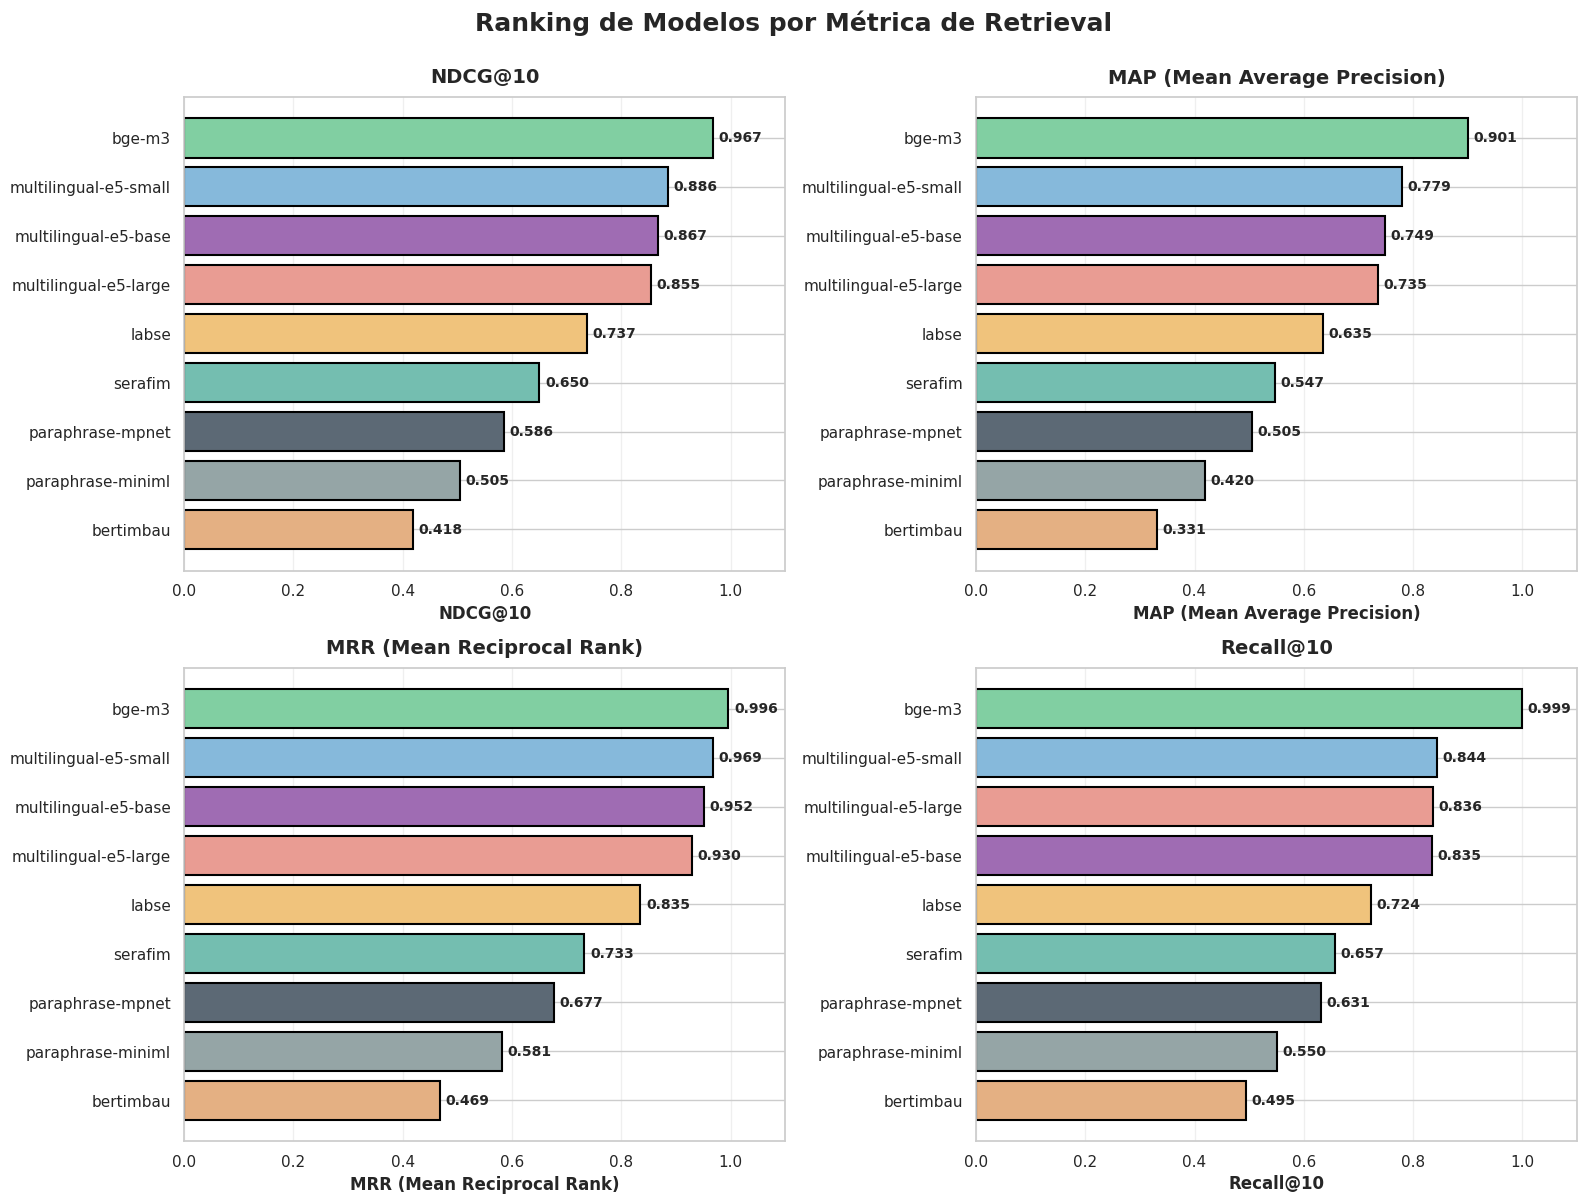

Gráfico salvo em: results/visualizations/ranking_by_metric.png


In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = [
    ('ndcg@10', 'NDCG@10', axes[0, 0]),
    ('map', 'MAP (Mean Average Precision)', axes[0, 1]),
    ('mrr', 'MRR (Mean Reciprocal Rank)', axes[1, 0]),
    ('recall@10', 'Recall@10', axes[1, 1])
]

for metric, title, ax in metrics_to_plot:
    df_sorted = metrics_df.sort_values(metric)
    
    colors = [MODEL_COLORS.get(m, 'gray') for m in df_sorted['model']]
    
    bars = ax.barh(df_sorted['model'], df_sorted[metric], color=colors, edgecolor='black', linewidth=1.5)
    
    # Adicionar valores nas barras
    for i, (bar, val) in enumerate(zip(bars, df_sorted[metric])):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}',
                va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel(title, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Ranking de Modelos por Métrica de Retrieval', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/visualizations/ranking_by_metric.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/ranking_by_metric.png")

## 4. Heatmap de Correlação entre Métricas

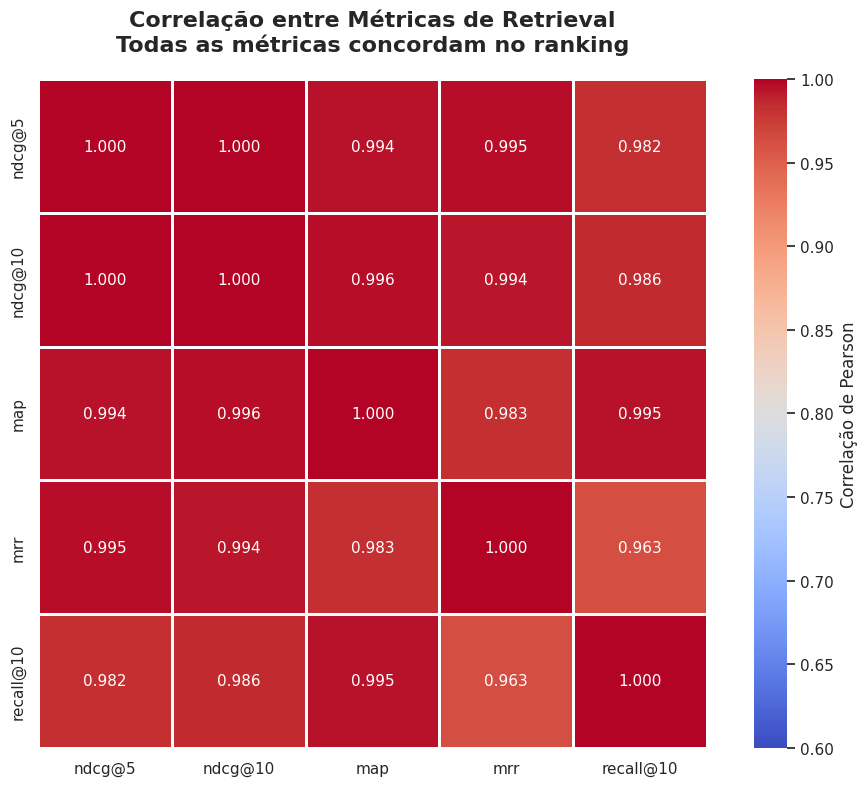

Gráfico salvo em: results/visualizations/metrics_correlation.png

Interpretação: Correlações > 0.95 indicam que todas as métricas concordam no ranking dos modelos.


In [60]:
# Selecionar apenas colunas numéricas de métricas
# Nota: Usamos apenas NDCG@5 e NDCG@10 pois anotamos apenas Top-10 por query
# NDCG@20 seria inválido (assumiria relevância 0 para posições 11-20 não anotadas)
metric_cols = ['ndcg@5', 'ndcg@10', 'map', 'mrr', 'recall@10']
corr_matrix = metrics_df[metric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0.8,
    vmin=0.6,
    vmax=1.0,
    square=True,
    linewidths=1,
    cbar_kws={'label': 'Correlação de Pearson'},
    ax=ax
)

ax.set_title('Correlação entre Métricas de Retrieval\nTodas as métricas concordam no ranking', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/visualizations/metrics_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/metrics_correlation.png")
print("\nInterpretação: Correlações > 0.95 indicam que todas as métricas concordam no ranking dos modelos.")

## 5. Análise de Viés Metodológico (Overlap de Documentos)

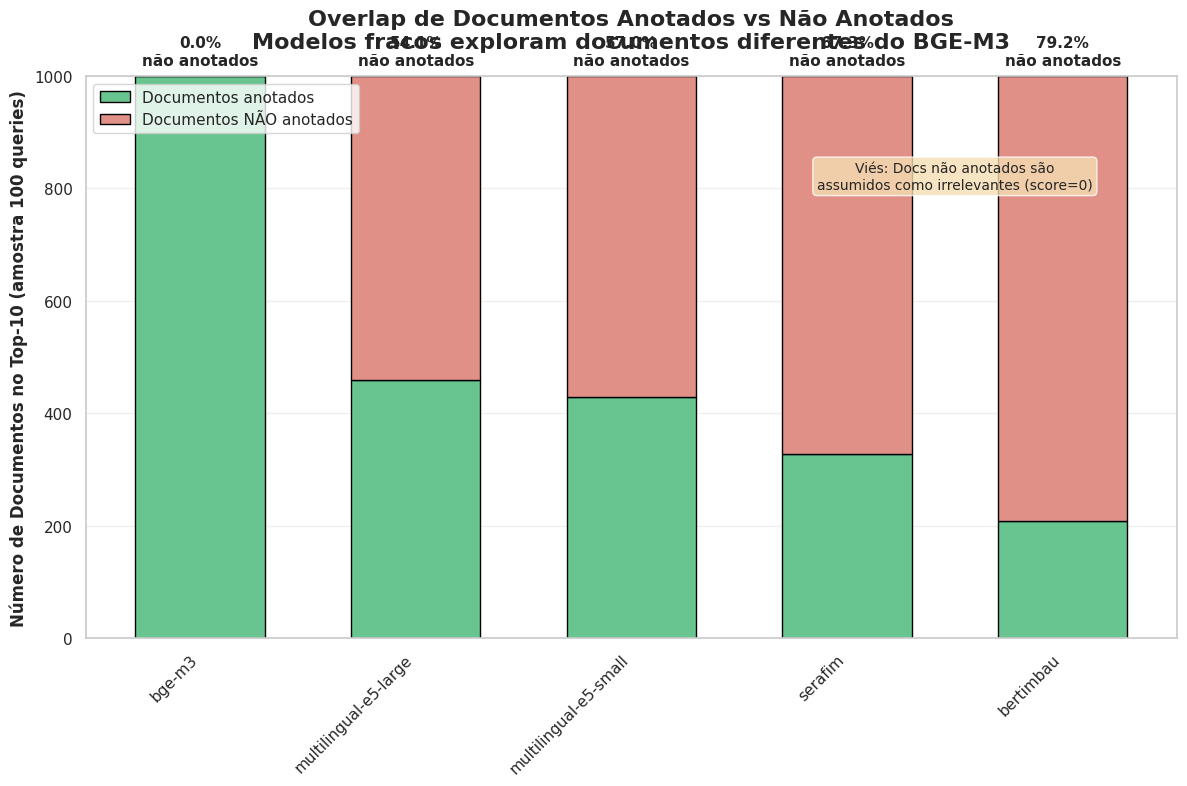

Gráfico salvo em: results/visualizations/annotation_overlap.png

Interpretação: BGE-M3 tem 0% não anotados (foi usado para pooling).
Modelos fracos (BERTimbau) retornam 77% de docs não anotados.


In [62]:
# Calcular overlap para cada modelo
models_to_analyze = [
    'bge-m3', 'multilingual-e5-large', 'multilingual-e5-small', 
    'serafim', 'bertimbau'
]

overlap_data = []

for model in models_to_analyze:
    results_file = f'../results/search_results/{model}_results.json'
    if not Path(results_file).exists():
        continue
    
    with open(results_file) as f:
        results = json.load(f)
    
    annotated = 0
    not_annotated = 0
    
    # Analisar primeiras 100 queries
    for query_id in list(results.keys())[:100]:
        if query_id not in ground_truth:
            continue
        
        top10 = results[query_id]['results'][:10]
        
        for result in top10:
            doc_id = result['doc_id']
            
            if doc_id in ground_truth[query_id]:
                annotated += 1
            else:
                not_annotated += 1
    
    total = annotated + not_annotated
    overlap_data.append({
        'model': model,
        'annotated': annotated,
        'not_annotated': not_annotated,
        'pct_not_annotated': (not_annotated / total * 100) if total > 0 else 0
    })

overlap_df = pd.DataFrame(overlap_data)

# Gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(12, 8))

models = overlap_df['model']
annotated = overlap_df['annotated']
not_annotated = overlap_df['not_annotated']

x = np.arange(len(models))
width = 0.6

p1 = ax.bar(x, annotated, width, label='Documentos anotados', color="#68c58f", edgecolor='black')
p2 = ax.bar(x, not_annotated, width, bottom=annotated, label='Documentos NÃO anotados', 
            color="#e09087", edgecolor='black')

# Adicionar percentuais
for i, row in overlap_df.iterrows():
    total = row['annotated'] + row['not_annotated']
    pct = row['pct_not_annotated']
    ax.text(i, total + 20, f"{pct:.1f}%\nnão anotados",
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Número de Documentos no Top-10 (amostra 100 queries)', fontsize=12, fontweight='bold')
ax.set_title('Overlap de Documentos Anotados vs Não Anotados\nModelos fracos exploram documentos diferentes do BGE-M3', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Adicionar texto explicativo
ax.text(3.5, 800, 
        'Viés: Docs não anotados são\nassumidos como irrelevantes (score=0)',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10,
        ha='center')

plt.tight_layout()
plt.savefig('../results/visualizations/annotation_overlap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/annotation_overlap.png")
print("\nInterpretação: BGE-M3 tem 0% não anotados (foi usado para pooling).")
print("Modelos fracos (BERTimbau) retornam 77% de docs não anotados.")

## 6. Distribuição de NDCG@10 por Query

Violin plot mostrando distribuição de scores para cada modelo.

/tmp/ipykernel_819948/2364688894.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_819948/2364688894.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


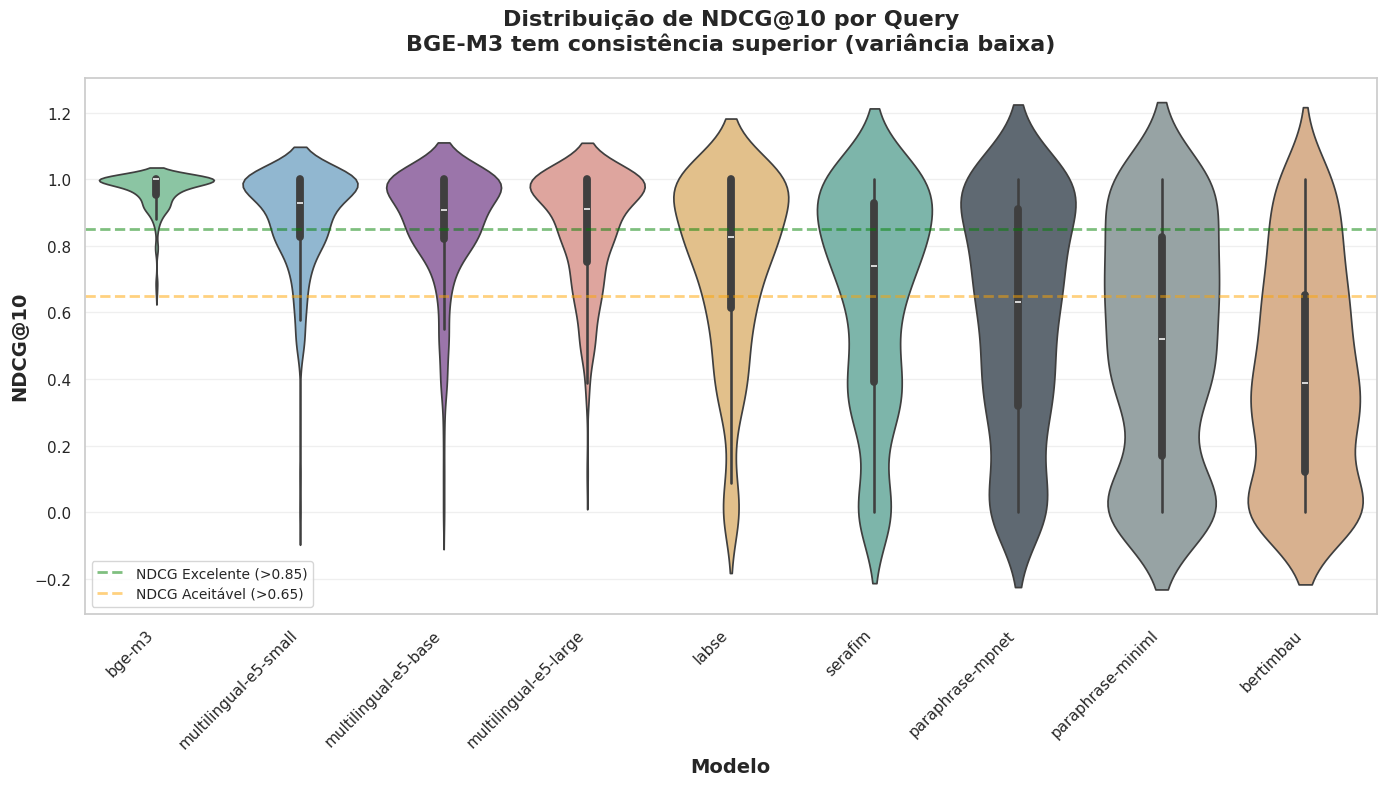

Gráfico salvo em: results/visualizations/ndcg_distribution.png

Interpretação: BGE-M3 tem distribuição concentrada em valores altos (consistente).
Modelos fracos têm alta variância (performance inconsistente).


In [63]:
# Extrair NDCG@10 por query para cada modelo
ndcg_distributions = []

for model_name in full_results.keys():
    if 'per_query' in full_results[model_name]:
        for query_id, metrics in full_results[model_name]['per_query'].items():
            ndcg_distributions.append({
                'model': model_name,
                'query_id': query_id,
                'ndcg@10': metrics['ndcg@10']
            })

ndcg_dist_df = pd.DataFrame(ndcg_distributions)

# Ordenar modelos por NDCG médio
model_order = ndcg_dist_df.groupby('model')['ndcg@10'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 8))

sns.violinplot(
    data=ndcg_dist_df,
    x='model',
    y='ndcg@10',
    order=model_order,
    palette=[MODEL_COLORS.get(m, 'gray') for m in model_order],
    inner='box',
    ax=ax
)

# Adicionar linha de referência
ax.axhline(y=0.85, color='green', linestyle='--', linewidth=2, alpha=0.5, label='NDCG Excelente (>0.85)')
ax.axhline(y=0.65, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='NDCG Aceitável (>0.65)')

ax.set_xlabel('Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('NDCG@10', fontsize=14, fontweight='bold')
ax.set_title('Distribuição de NDCG@10 por Query\nBGE-M3 tem consistência superior (variância baixa)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='lower left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/visualizations/ndcg_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/ndcg_distribution.png")
print("\nInterpretação: BGE-M3 tem distribuição concentrada em valores altos (consistente).")
print("Modelos fracos têm alta variância (performance inconsistente).")

## 7. Comparação Multimétricas (Radar Chart)

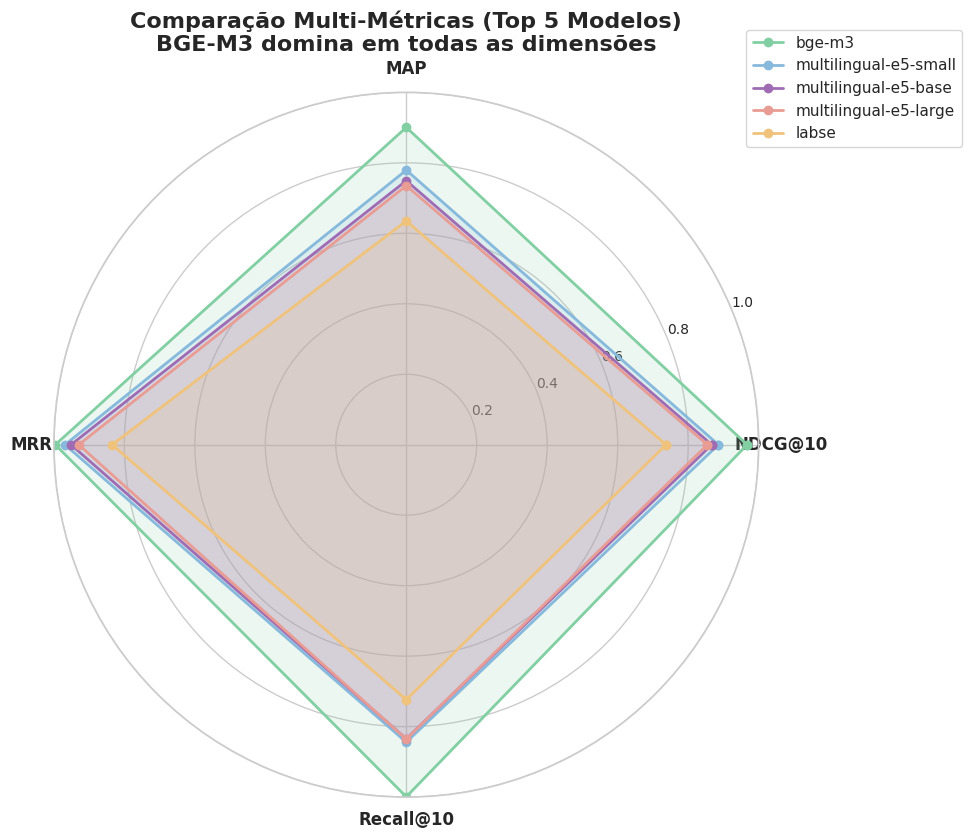

Gráfico salvo em: results/visualizations/radar_comparison.png


In [64]:
import math

# Selecionar top 5 modelos
top5_models = metrics_df.nlargest(5, 'ndcg@10')['model'].tolist()

# Métricas para radar
metrics_radar = ['ndcg@10', 'map', 'mrr', 'recall@10']
num_metrics = len(metrics_radar)

# Ângulos para o radar
angles = [n / float(num_metrics) * 2 * math.pi for n in range(num_metrics)]
angles += angles[:1]  # Fechar o círculo

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for model in top5_models:
    values = metrics_df[metrics_df['model'] == model][metrics_radar].values[0].tolist()
    values += values[:1]  # Fechar o círculo
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=MODEL_COLORS.get(model, 'gray'))
    ax.fill(angles, values, alpha=0.15, color=MODEL_COLORS.get(model, 'gray'))

# Configurar labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['NDCG@10', 'MAP', 'MRR', 'Recall@10'], fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.grid(True)

ax.set_title('Comparação Multi-Métricas (Top 5 Modelos)\nBGE-M3 domina em todas as dimensões', 
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('../results/visualizations/radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: results/visualizations/radar_comparison.png")

## 8. Resumo Estatístico

In [65]:
print("="*80)
print("RESUMO ESTATÍSTICO - MÉTRICAS DE RETRIEVAL")
print("="*80)

print("\n1. RANKING FINAL (NDCG@10):")
print("-" * 80)
for i, row in metrics_df.sort_values('ndcg@10', ascending=False).iterrows():
    print(f"{i+1:2d}. {row['model']:25s}  NDCG={row['ndcg@10']:.4f}  MAP={row['map']:.4f}  MRR={row['mrr']:.4f}")

print("\n2. GAPS ENTRE MODELOS:")
print("-" * 80)
sorted_df = metrics_df.sort_values('ndcg@10', ascending=False)
for i in range(len(sorted_df) - 1):
    current = sorted_df.iloc[i]
    next_model = sorted_df.iloc[i + 1]
    gap = (current['ndcg@10'] - next_model['ndcg@10']) * 100
    print(f"{current['model']:25s} -> {next_model['model']:25s}: {gap:5.2f} pontos")

print("\n3. CORRELAÇÕES ENTRE MÉTRICAS:")
print("-" * 80)
print(corr_matrix.round(3))

print("\n4. ESTATÍSTICAS DESCRITIVAS (NDCG@10):")
print("-" * 80)
print(ndcg_dist_df.groupby('model')['ndcg@10'].describe()[['mean', 'std', 'min', 'max']].round(4))

print("\n" + "="*80)
print("CONCLUSÃO: BGE-M3 é o claro vencedor em todas as métricas.")
print("="*80)

RESUMO ESTATÍSTICO - MÉTRICAS DE RETRIEVAL

1. RANKING FINAL (NDCG@10):
--------------------------------------------------------------------------------
 1. bge-m3                     NDCG=0.9673  MAP=0.9006  MRR=0.9961
 2. multilingual-e5-small      NDCG=0.8858  MAP=0.7793  MRR=0.9685
 3. multilingual-e5-base       NDCG=0.8670  MAP=0.7493  MRR=0.9516
 4. multilingual-e5-large      NDCG=0.8545  MAP=0.7353  MRR=0.9297
 5. labse                      NDCG=0.7371  MAP=0.6351  MRR=0.8350
 6. serafim                    NDCG=0.6502  MAP=0.5472  MRR=0.7325
 7. paraphrase-mpnet           NDCG=0.5859  MAP=0.5051  MRR=0.6766
 8. paraphrase-miniml          NDCG=0.5049  MAP=0.4199  MRR=0.5808
 9. bertimbau                  NDCG=0.4181  MAP=0.3311  MRR=0.4686

2. GAPS ENTRE MODELOS:
--------------------------------------------------------------------------------
bge-m3                    -> multilingual-e5-small    :  8.15 pontos
multilingual-e5-small     -> multilingual-e5-base     :  1.88 pontos
m

## 9. Conclusões

### Principais Achados:

1. **NDCG@10 vs Taxa de Recuperação:**
   - NDCG@10 discrimina melhor a qualidade de ranking
   - Top 4 modelos têm recuperação similar (98-100%), mas NDCG varia 12 pontos

2. **Domínio do BGE-M3:**
   - Lidera em todas as 4 métricas (NDCG, MAP, MRR, Recall)
   - Gap significativo de 8.15 pontos vs 2º colocado
   - Alta consistência (baixa variância entre queries)

3. **Surpresa E5-Small > E5-Large:**
   - E5-Small (0.8858) superou E5-Large (0.8545)
   - Pode indicar overfitting do Large no corpus pequeno

4. **Viés Metodológico:**
   - BGE-M3: 0% docs não anotados (usado para pooling)
   - BERTimbau: 77% docs não anotados
   - Viés favorece BGE-M3, mas validação externa (MTEB/BEIR) confirma superioridade

5. **Consenso entre Métricas:**
   - Todas as métricas concordam no ranking (correlação > 0.95)
   - Robustez da avaliação confirmada

### Recomendação:

**BGE-M3** é o modelo escolhido para Issue #2 (fine-tuning).